<a href="https://colab.research.google.com/github/BY50/CP1SERS2Semestre/blob/main/CP1SERS2SemestreDesafioFinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Desafio Final — Análise de Dados de Energia com API Pública

**Curso:** Ciência da Computação  
**Disciplina:** Soluções em Energias Renováveis e Sustentáveis

## Situação-problema

Uma equipe de planejamento energético precisa analisar o comportamento da carga elétrica de uma região atendida pelo Sistema Interligado Nacional (SIN).

Os dados serão obtidos diretamente de uma API pública do **Operador Nacional do Sistema Elétrico (ONS)**. A conexão com a API e a preparação inicial do JSON já estão fornecidas. A partir daí, sua equipe deverá construir o DataFrame, organizar os dados, criar recortes, calcular indicadores, produzir gráficos e elaborar um relatório técnico.

> Todos os códigos, resultados, gráficos e respostas devem permanecer neste mesmo Notebook.

## 1. Fonte dos dados

API pública de **Carga Verificada do ONS**:

- Portal: https://dados.ons.org.br/
- Conjunto de dados: https://dados.ons.org.br/dataset/carga-energia-verificada

Neste notebook será utilizada inicialmente a área **SP — São Paulo**, no período de **01/08/2025 a 07/08/2025**.

## 2. Bibliotecas

In [ ]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 3. Consulta à API

Esta célula está pronta. Não é necessário conhecer `requests` para realizar o desafio.

In [ ]:
url = "https://apicarga.ons.org.br/prd/cargaverificada"

parametros = {
    "dat_inicio": "2025-08-01",
    "dat_fim": "2025-08-07",
    "cod_areacarga": "SP"
}

response = requests.get(url, params=parametros, timeout=30)

print("Status:", response.status_code)
print("URL:", response.url)

response.raise_for_status()
dados_json = response.json()

Status: 200
URL: https://apicarga.ons.org.br/prd/cargaverificada?dat_inicio=2025-08-01&dat_fim=2025-08-07&cod_areacarga=SP


## 4. Preparação inicial do JSON

A célula abaixo localiza a lista principal de registros retornada pela API e a armazena em `registros`.

In [ ]:
if isinstance(dados_json, list):
    registros = dados_json

elif isinstance(dados_json, dict):
    chaves_com_lista = [
        chave for chave, valor in dados_json.items()
        if isinstance(valor, list)
    ]

    if not chaves_com_lista:
        raise ValueError("A resposta não contém uma lista de registros.")

    chave_registros = chaves_com_lista[0]
    registros = dados_json[chave_registros]
    print("Chave utilizada:", chave_registros)

else:
    raise TypeError("Formato de JSON não reconhecido.")

print("Tipo:", type(registros))
print("Quantidade de registros:", len(registros))

if registros:
    print("\nPrimeiro registro:")
    print(registros[0])

Tipo: <class 'list'>
Quantidade de registros: 336

Primeiro registro:
{'cod_areacarga': 'SP', 'din_atualizacao': '2026-08-14T05:58:29.574Z', 'dat_referencia': '2025-08-01', 'din_referenciautc': '2025-08-01T03:30:00.000Z', 'val_cargaglobal': 15913.618, 'val_cargaglobalcons': 15913.618, 'val_cargaglobalsmmgd': 15892.488, 'val_cargasupervisionada': 14421.112, 'val_carganaosupervisionada': 1471.3759, 'val_cargammgd': 21.13, 'val_consistencia': 0}


In [ ]:
type(registros)

list

In [ ]:
registros

[{'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T03:30:00.000Z',
  'val_cargaglobal': 15913.618,
  'val_cargaglobalcons': 15913.618,
  'val_cargaglobalsmmgd': 15892.488,
  'val_cargasupervisionada': 14421.112,
  'val_carganaosupervisionada': 1471.3759,
  'val_cargammgd': 21.13,
  'val_consistencia': 0},
 {'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T04:00:00.000Z',
  'val_cargaglobal': 15251.414,
  'val_cargaglobalcons': 15251.414,
  'val_cargaglobalsmmgd': 15230.284,
  'val_cargasupervisionada': 13758.101,
  'val_carganaosupervisionada': 1472.184,
  'val_cargammgd': 21.13,
  'val_consistencia': 0},
 {'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T04:30:00.000Z',
  'val_cargaglobal': 14606.733,
  'val_carga

# A partir daqui, o trabalho é da equipe

## DESAFIO 1 — Construção e inspeção do DataFrame

1. Crie um DataFrame Pandas chamado `dados` a partir de `registros`.
2. Exiba os primeiros registros.
3. Determine a quantidade de linhas e colunas.
4. Liste os nomes dos atributos.
5. Utilize `info()`.
6. Utilize `describe()`.
7. Em Markdown, identifique quais atributos representam data/hora, área de carga e valor de carga.

**Antes de prosseguir, compreenda a estrutura efetivamente retornada pela API.**

In [ ]:
dados = pd.DataFrame(registros)
dados.head()

,cod_areacarga,din_atualizacao,dat_referencia,din_referenciautc,val_cargaglobal,val_cargaglobalcons,val_cargaglobalsmmgd,val_cargasupervisionada,val_carganaosupervisionada,val_cargammgd,val_consistencia
0,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T03:30:00.000Z,15913.618,15913.618,15892.488,14421.112,1471.3759,21.13,0
1,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T04:00:00.000Z,15251.414,15251.414,15230.284,13758.101,1472.1840,21.13,0
2,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T04:30:00.000Z,14606.733,14606.733,14585.604,13112.602,1473.0022,21.13,0
3,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T05:00:00.000Z,14182.290,14182.290,14161.160,12687.433,1473.7275,21.13,0
4,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T05:30:00.000Z,13838.488,13838.488,13817.358,12342.648,1474.7096,21.13,0


In [ ]:
print(f"Número de linhas: {dados.shape[0]}, número de colunas: {dados.shape[1]}")

Número de linhas: 336, número de colunas: 11


In [ ]:
dados.columns

Index(['cod_areacarga', 'din_atualizacao', 'dat_referencia',
       'din_referenciautc', 'val_cargaglobal', 'val_cargaglobalcons',
       'val_cargaglobalsmmgd', 'val_cargasupervisionada',
       'val_carganaosupervisionada', 'val_cargammgd', 'val_consistencia'],
      dtype='object')

In [ ]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 336 entries, 0 to 335
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   cod_areacarga               336 non-null    object 
 1   din_atualizacao             336 non-null    object 
 2   dat_referencia              336 non-null    object 
 3   din_referenciautc           336 non-null    object 
 4   val_cargaglobal             336 non-null    float64
 5   val_cargaglobalcons         336 non-null    float64
 6   val_cargaglobalsmmgd        336 non-null    float64
 7   val_cargasupervisionada     336 non-null    float64
 8   val_carganaosupervisionada  336 non-null    float64
 9   val_cargammgd               336 non-null    float64
 10  val_consistencia            336 non-null    int64  
dtypes: float64(6), int64(1), object(4)
memory usage: 29.0+ KB


In [ ]:
dados.describe()

,val_cargaglobal,val_cargaglobalcons,val_cargaglobalsmmgd,val_cargasupervisionada,val_carganaosupervisionada,val_cargammgd,val_consistencia
count,336.000000,336.000000,336.000000,336.000000,336.000000,336.000000,336.0
mean,17870.828981,17870.828981,16953.421626,15495.799695,1457.621862,917.407249,0.0
std,3029.042438,3029.042438,2962.721503,2982.650359,34.888571,1253.581141,0.0
min,12139.253000,12139.253000,11549.664000,10054.455000,1391.990800,21.130000,0.0
25%,15110.533375,15110.533375,14457.604250,12990.878500,1433.112575,21.130000,0.0
50%,18199.128500,18199.128500,17045.260000,15611.629500,1453.981650,21.196900,0.0
75%,20386.629500,20386.629500,18931.679500,17502.643500,1479.430775,1793.579475,0.0
max,23185.312000,23185.312000,23164.182000,21717.934000,1538.274700,3736.009800,0.0


Os aributos que representam Data/Hora são: din_atualizacao, dat_referencia e din_referenciautc; o atributo que representa área de carga é cod_areacarga e os atributos que representam valor da carga são os atributos que começam com val, exceto val_consistencia.

## DESAFIO 2 — Organização dos dados

1. Renomeie os principais atributos com nomes mais simples.
2. Crie um novo DataFrame contendo apenas os atributos necessários.
3. Verifique valores ausentes.
4. Caso existam, informe quantos há em cada atributo relevante.
5. Verifique se a variável de carga está em formato numérico.
6. Verifique como a data/hora está representada.
7. Registre em Markdown qualquer decisão de tratamento.

In [ ]:
dados.rename({"cod_areacarga": "AreaDeCarga", "din_referenciautc": "Data/Hora",
"val_cargaglobal": "CargaGlobal"}, axis = 1, inplace = True)
dados.head()

,AreaDeCarga,din_atualizacao,dat_referencia,Data/Hora,CargaGlobal,val_cargaglobalcons,val_cargaglobalsmmgd,val_cargasupervisionada,val_carganaosupervisionada,val_cargammgd,val_consistencia
0,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T03:30:00.000Z,15913.618,15913.618,15892.488,14421.112,1471.3759,21.13,0
1,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T04:00:00.000Z,15251.414,15251.414,15230.284,13758.101,1472.1840,21.13,0
2,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T04:30:00.000Z,14606.733,14606.733,14585.604,13112.602,1473.0022,21.13,0
3,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T05:00:00.000Z,14182.290,14182.290,14161.160,12687.433,1473.7275,21.13,0
4,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T05:30:00.000Z,13838.488,13838.488,13817.358,12342.648,1474.7096,21.13,0


In [ ]:
dados2 = dados[["AreaDeCarga", "Data/Hora", "CargaGlobal"]]
dados2.head()

,AreaDeCarga,Data/Hora,CargaGlobal
0,SP,2025-08-01T03:30:00.000Z,15913.618
1,SP,2025-08-01T04:00:00.000Z,15251.414
2,SP,2025-08-01T04:30:00.000Z,14606.733
3,SP,2025-08-01T05:00:00.000Z,14182.290
4,SP,2025-08-01T05:30:00.000Z,13838.488


In [ ]:
dados2.isnull().sum()

,0
AreaDeCarga,0
Data/Hora,0
CargaGlobal,0


In [ ]:
print("Não há valores ausentes nos atributos do dataframe.")

Não há valores ausentes nos atributos do dataframe.


In [ ]:
dados2.info()
print("A variável de carga está em valor numérico (float).")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 336 entries, 0 to 335
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   AreaDeCarga  336 non-null    object 
 1   Data/Hora    336 non-null    object 
 2   CargaGlobal  336 non-null    float64
dtypes: float64(1), object(2)
memory usage: 8.0+ KB
A variável de carga está em valor numérico (float).


In [ ]:
print("A Data está representada no formato YYYY-MM-DD (Ano-Mes-Dia) e a Hora no formato THH:MM:SSZ (formato UTC).")

A Data está representada no formato YYYY-MM-DD (Ano-Mes-Dia) e a Hora no formato THH:MM:SSZ (formato UTC).


Os atributos cod_areacarga, din_referenciautc e val_cargaglobal foram renomeados para AreaDeCarga, Data/Hora e CargaGlobal respectivamente. Foi criado um novo dataframe com só esses 3 atributos.

## DESAFIO 3 — Indicadores da carga elétrica

Calcule:

1. carga mínima;
2. carga máxima;
3. carga média;
4. mediana;
5. amplitude entre máximo e mínimo;
6. quantidade total de medições.

Depois responda:

**O valor máximo está muito distante do comportamento médio observado? Justifique com os indicadores calculados.**

In [ ]:
min = dados2["CargaGlobal"].min()
print(f"A carga mínima é {min}.")

A carga mínima é 12139.253.


In [ ]:
max = dados2["CargaGlobal"].max()
print(f"A carga máxima é {max}.")

A carga máxima é 23185.312.


In [ ]:
media = dados2["CargaGlobal"].mean()
print(f"A carga média é {media}.")

A carga média é 17870.828980654762.


In [ ]:
mediana = dados2["CargaGlobal"].median()
print(f"A carga mediana é {mediana}.")

A carga mediana é 18199.1285.


In [ ]:
print(f"A amplitude entre o máximo e o mínimo é {max - min}.")

A amplitude entre o máximo e o mínimo é 11046.059000000001.


In [ ]:
total = dados2["CargaGlobal"].count()
print(f"A quantidade total de medições é {total}.")

A quantidade total de medições é 336.


O valor máximo não está muito distante do comportamento médio, com sua distância à média e mediana sendo parecida com a distância que o valor mínimo possui.

## DESAFIO 4 — Períodos de alta demanda

Considere como **alta demanda** os registros com carga superior a **90% da carga máxima**.

1. Calcule o limiar.
2. Crie um novo DataFrame com os registros acima dele.
3. Conte os registros.
4. Calcule o percentual em relação ao total.
5. Identifique o maior valor de carga.
6. Identifique a data e o horário do pico, quando disponíveis.

Responda:

**Os períodos próximos ao pico representam uma parcela grande ou pequena do período analisado?**

In [ ]:
limiar90 = max * 0.9
print(f"O limiar de 90% da carga máxima é {limiar90}.")

O limiar de 90% da carga máxima é 20866.7808.


In [ ]:
dados3 = dados2[dados2["CargaGlobal"] > limiar90]
dados3.head()

,AreaDeCarga,Data/Hora,CargaGlobal
35,SP,2025-08-01T21:00:00.000Z,21088.959
36,SP,2025-08-01T21:30:00.000Z,22398.360
37,SP,2025-08-01T22:00:00.000Z,23185.312
38,SP,2025-08-01T22:30:00.000Z,22903.314
39,SP,2025-08-01T23:00:00.000Z,22358.701


In [ ]:
numAcima90 = dados3["CargaGlobal"].count()
print(f"A quantidade da amostra que está acima de 90% da carga máxima é {numAcima90}.")

A quantidade da amostra que está acima de 90% da carga máxima é 50.


In [ ]:
percent = numAcima90 / total
print(f"O percentual da amostra que está acima de 90% da carga máxima é {percent * 100}%.")

O percentual da amostra que está acima de 90% da carga máxima é 14.880952380952381%.


In [ ]:
print(f"O maior valor de carga é {max}.")

O maior valor de carga é 23185.312.


In [ ]:
pico = dados3[dados3["CargaGlobal"] == max]
print(pico)
print("A data do pico é 01/08/2025 e a hora é 22:00:00.")

   AreaDeCarga                 Data/Hora  CargaGlobal
37          SP  2025-08-01T22:00:00.000Z    23185.312
A data do pico é 01/08/2025 e a hora é 22:00:00.


Os períodos próximos ao pico representam uma parcela pequena do período analisado, sendo só aproximadamente 15% do total.

## DESAFIO 5 — Segundo critério de análise

Crie um segundo recorte dos dados utilizando um critério definido pela equipe.

Possibilidades:

- carga acima da média;
- carga abaixo de uma porcentagem do máximo;
- intervalo de valores;
- determinado dia ou período;
- combinação de duas condições.

Apresente:

1. o critério escolhido;
2. o novo DataFrame;
3. a quantidade de registros;
4. o percentual;
5. a comparação com o conjunto de alta demanda.

In [ ]:
print("O critério escolhido foi de registros com a carga acima da média.")

O critério escolhido foi de registros com a carga acima da média.


In [ ]:
dados4 = dados2[dados2["CargaGlobal"] > media]
dados4.head()

,AreaDeCarga,Data/Hora,CargaGlobal
15,SP,2025-08-01T11:00:00.000Z,18096.023
16,SP,2025-08-01T11:30:00.000Z,18629.395
17,SP,2025-08-01T12:00:00.000Z,18825.176
18,SP,2025-08-01T12:30:00.000Z,19056.504
19,SP,2025-08-01T13:00:00.000Z,19427.822


In [ ]:
numAcimaMedia = dados4["CargaGlobal"].count()
print(f"A quantidade da amostra que está acima da carga média é {numAcimaMedia}.")

A quantidade da amostra que está acima da carga média é 184.


In [ ]:
percent2 = numAcimaMedia / total
print(f"O percentual da amostra que está acima da carga média é {percent2 * 100}%.")

O percentual da amostra que está acima da carga média é 54.761904761904766%.


Este conjunto representa um maior percentual da amostra total que o conjunto de alta demanda, o que era esperado.

## DESAFIO 6 — Visualização

Construa **pelo menos dois gráficos**.

- Um deve representar o comportamento da carga ao longo das observações ou do tempo.
- O segundo deve ser escolhido pela equipe.

Inclua título, eixos e unidades quando aplicável.

Após cada gráfico, escreva uma interpretação curta.

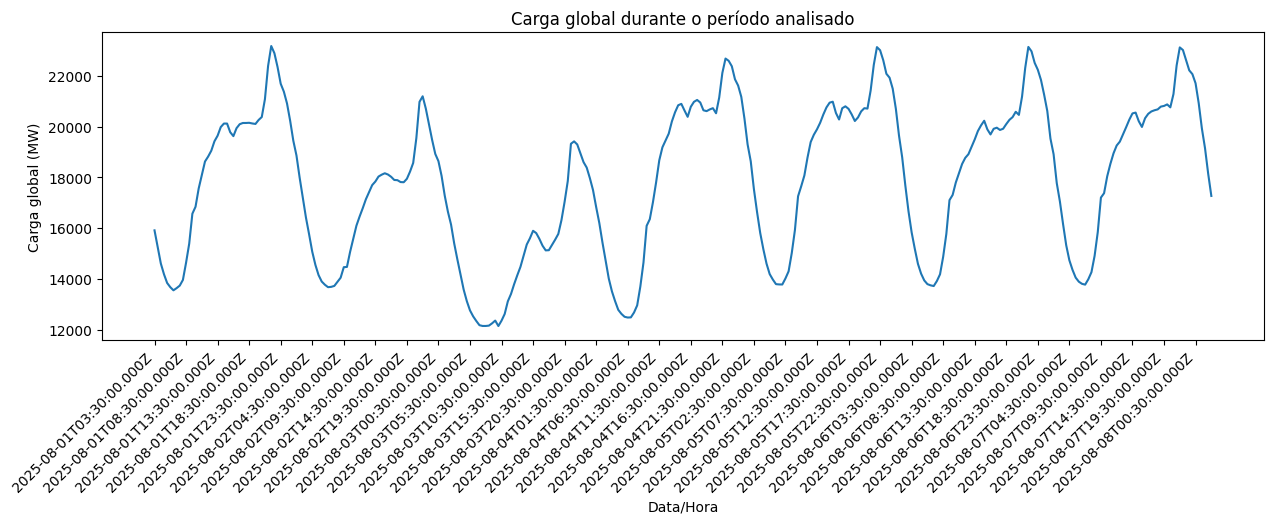

In [ ]:
import numpy as np
fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(dados2["Data/Hora"], dados2["CargaGlobal"])
plt.title("Carga global durante o período analisado")
plt.xlabel("Data/Hora")
plt.ylabel("Carga global (MW)")
ax.set_xticks(np.arange(0, dados2["Data/Hora"].count(), 10))
ax.set_xticklabels(dados2["Data/Hora"][::10], rotation = 45, ha = "right")
plt.show()

O gráfico apresenta uma repetição geral de um período de alta, seguido de uma pequena queda, então uma outra alta e depois uma grande queda. Esse comportamento indica que a demanda cai durante a manhã e tem um pico durante a noite.

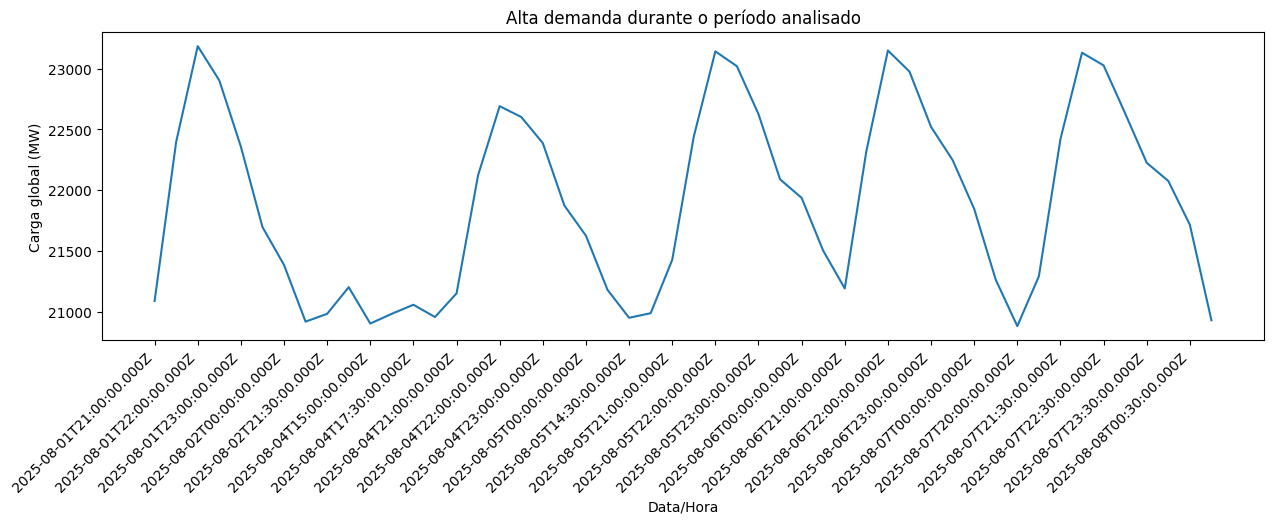

In [ ]:
fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(dados3["Data/Hora"], dados3["CargaGlobal"])
plt.title("Alta demanda durante o período analisado")
plt.xlabel("Data/Hora")
plt.ylabel("Carga global (MW)")
ax.set_xticks(np.arange(0, dados3["Data/Hora"].count(), 2))
ax.set_xticklabels(dados3["Data/Hora"][::2], rotation = 45, ha = "right")
plt.show()

Este gráfico indica que os dias 2 e 3 demonstraram uma demanda geralmente menor que os outros dias e que períodos mais tardes da noite mostram maior demanda.

## DESAFIO 7 — Síntese para o relatório

Crie uma variável `resumo_resultados` contendo pelo menos:

- região;
- período;
- quantidade de registros;
- carga mínima;
- carga máxima;
- carga média;
- mediana;
- limiar de alta demanda;
- quantidade e percentual de alta demanda;
- momento do pico;
- resultado do segundo critério.

A IA deverá receber **resultados produzidos por vocês**, e não substituir a análise.

In [ ]:
resumo_resultados = {"Região analisada": "SP",
                     "Período analisado": ["01/08/2025", "02/08/2025", "03/08/2025", "04/08/2025", "05/08/2025", "06/08/2025", "07/08/2025"],
                     "Quantidade de registros": total,
                     "Carga mínima": min,
                     "Carga máxima": max,
                     "Carga média": media,
                     "Mediana": mediana,
                     "Limiar de alta demanda": limiar90,
                     "Registros de alta demanda": numAcima90,
                     "Percentual de alta demanda": percent * 100,
                     "Momento do pico": "Dia: 1/08/2025, Hora: 22:00:00",
                     "Segundo critério": "Carga acima da média",
                     "Registros acima da média": numAcimaMedia,
                     "Percentual acima da média": percent2 * 100}
print(resumo_resultados)

{'Região analisada': 'SP', 'Período analisado': ['01/08/2025', '02/08/2025', '03/08/2025', '04/08/2025', '05/08/2025', '06/08/2025', '07/08/2025'], 'Quantidade de registros': np.int64(336), 'Carga mínima': 12139.253, 'Carga máxima': 23185.312, 'Carga média': np.float64(17870.828980654762), 'Mediana': 18199.1285, 'Limiar de alta demanda': 20866.7808, 'Registros de alta demanda': np.int64(50), 'Percentual de alta demanda': np.float64(14.880952380952381), 'Momento do pico': 'Dia: 1/08/2025, Hora: 22:00:00', 'Segundo critério': 'Carga acima da média', 'Registros acima da média': np.int64(184), 'Percentual acima da média': np.float64(54.761904761904766)}


# OPCIONAL: Relatório técnico com apoio do Gemini

No Colab:

1. abra **Secrets**;
2. crie `GEMINI_API_KEY`;
3. informe sua chave;
4. permita o acesso do notebook ao secret.

**Não coloque a chave diretamente no código.**

In [ ]:
!pip -q install -U google-genai

In [ ]:
from google.colab import userdata
from google import genai

GEMINI_API_KEY = userdata.get("GEMINI_API_KEY")
client = genai.Client(api_key=GEMINI_API_KEY)

## DESAFIO 8 — Geração do relatório

O relatório deve:

- usar os resultados calculados;
- apresentar os principais indicadores;
- destacar o pico e os períodos de alta demanda;
- comparar os dois critérios;
- não inventar causas;
- diferenciar observações de hipóteses;
- terminar com uma conclusão.

In [ ]:
prompt = f'''
Atue como analista de dados do setor elétrico.

Produza um relatório técnico curto com base EXCLUSIVAMENTE nos resultados abaixo.

Não invente causas para as variações observadas.
Não apresente como fato explicações que não possam ser sustentadas pelos dados.
Diferencie claramente resultados observados de hipóteses.

Inclua:
1. caracterização do conjunto analisado;
2. principais indicadores;
3. análise dos períodos de alta demanda;
4. comparação com o segundo critério;
5. conclusão.

RESULTADOS DA EQUIPE:

{resumo_resultados}
'''

In [ ]:
response_gemini = client.models.generate_content(
    model="gemini-3.6-flash",
    contents=prompt
)

print(response_gemini.text)

## DESAFIO 9 — Validação crítica

Compare o texto gerado pelo Gemini com os cálculos, DataFrames e gráficos.

Responda:

1. Os indicadores foram utilizados corretamente?
2. Há alguma afirmação que não pode ser confirmada pelos dados?
3. Houve interpretação exagerada ou causalidade não demonstrada?
4. Que alterações a equipe realizou no texto?

## Relatório final

Insira abaixo a versão final revisada pela equipe.

_Escreva aqui a versão final revisada._

---

## Entrega

O notebook deve apresentar:

- consulta à API executada;
- DataFrame criado;
- inspeção e organização dos dados;
- indicadores;
- pelo menos dois DataFrames derivados por critérios;
- percentuais;
- pelo menos dois gráficos;
- interpretações;
- síntese para a IA;
- relatório com apoio do Gemini;
- validação crítica;
- versão final revisada.

**Entregue somente este Notebook (.ipynb), com todas as células executadas e os resultados visíveis.**